In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [101]:
filebase='test1d'
Ns=[128]
n=1
ndim=len(Ns)
ys=np.fromfile(filebase+'states.dat').reshape([-1]+[n]+Ns)
fs=np.fromfile(filebase+'f.dat').reshape([-1]+[n]+Ns)
print(fs.shape)
print(ys.shape)

(101, 1, 128)
(101, 1, 128)


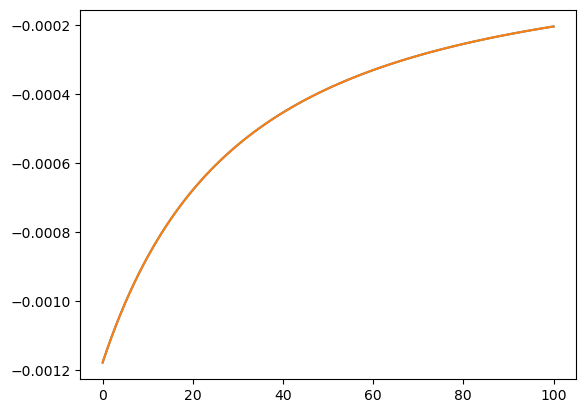

In [103]:
plt.plot(-fs[:,0,1])
plt.plot(ys[:,0,1]**3)

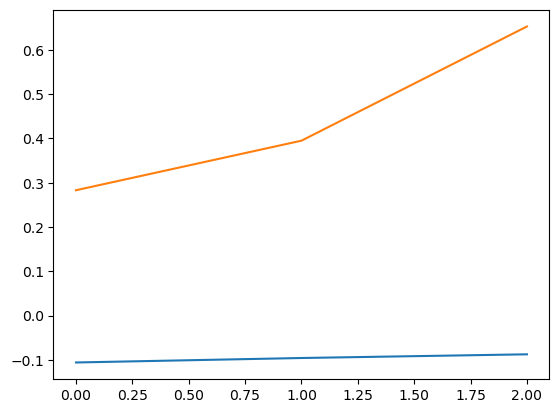

In [79]:
plt.plot(ys[:,0,1])
plt.plot(ys[:,0,2])

In [63]:
N=128
L=100
print(np.fft.fftfreq(N,L/(2*np.pi*N))-np.fft.fftfreq(N,1.0)*2*np.pi*N/L)
print(np.fft.fftfreq(N,L/(2*np.pi*N))**2-(np.fft.fftfreq(N,1.0)*2*np.pi*N/L)**2)

[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  2.77555756e-17
  0.00000000e+00  0.00000000e+00  5.55111512e-17  5.55111512e-17
  0.00000000e+00  0.00000000e+00  0.00000000e+00  1.11022302e-16
  1.11022302e-16  0.00000000e+00  1.11022302e-16  2.22044605e-16
  0.00000000e+00  0.00000000e+00  0.00000000e+00  2.22044605e-16
  0.00000000e+00  0.00000000e+00  2.22044605e-16  2.22044605e-16
  2.22044605e-16  2.22044605e-16  0.00000000e+00  2.22044605e-16
  2.22044605e-16  0.00000000e+00  4.44089210e-16  2.22044605e-16
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  4.44089210e-16  4.44089210e-16
  0.00000000e+00  4.44089210e-16  0.00000000e+00  4.44089210e-16
  4.44089210e-16  4.44089210e-16  4.44089210e-16  0.00000000e+00
  4.44089210e-16  4.44089210e-16  4.44089210e-16  0.00000000e+00
  0.00000000e+00  0.00000000e+00  4.44089210e-16  4.44089210e-16
  4.44089210e-16  4.44089210e-16  0.00000000e+00  4.44089210e-16
  8.88178420e-16  4.44089

In [12]:
nfields=4
ndim=1
Ns=[128]
y=np.fromfile('test1dy.dat').reshape([nfields]+Ns)
Y=np.fromfile('test1dY.dat',dtype=complex).reshape([nfields*(1+ndim+ndim**2)]+Ns)

for i in range(nfields):
    print('a',i,np.linalg.norm(np.real(Y[i])-y[i]))
    yfft=np.fft.fftn(y[i])
    for j in range(ndim):
        fshape=[1]*ndim
        fshape[j]=Ns[j]
        freqs=1j*np.fft.fftfreq(Ns[j],1).reshape(fshape)
        yp=np.real(np.fft.ifftn(freqs*yfft))
        print('b',i,j,nfields+i*ndim+j,np.linalg.norm(np.real(Y[nfields+i+j*nfields])-yp))
        for k in range(ndim):
            fshape2=[1]*ndim
            fshape2[k]=Ns[k]
            freqs2=1j*np.fft.fftfreq(Ns[k],1).reshape(fshape2)
            ypp=np.real(np.fft.ifftn(freqs*freqs2*yfft))
            print('c',i,j,k,nfields+nfields*ndim+i*ndim*ndim+j*ndim+k,np.linalg.norm(np.real(Y[nfields+nfields*ndim+i+j*nfields+k*nfields*ndim])-ypp))



a 0 6.910130033803578e-16
b 0 0 4 2.4627575382182347e-16
c 0 0 0 8 8.594762695771993e-17
a 1 6.98178250108387e-16
b 1 0 5 2.7185945195240165e-16
c 1 0 0 9 1.0253686923663445e-16
a 2 6.495931425247986e-16
b 2 0 6 2.2968714910700656e-16
c 2 0 0 10 7.901803486151581e-17
a 3 5.950076235032486e-16
b 3 0 7 2.442050773456542e-16
c 3 0 0 11 8.518379897522737e-17


In [19]:
nfields=4
ndim=2
Ns=[128,64]
y=np.fromfile('test2dy.dat').reshape([nfields]+Ns)
Y=np.fromfile('test2dY.dat',dtype=complex).reshape([nfields*(1+ndim+ndim**2)]+Ns)

for i in range(nfields):
    print('a',i,np.linalg.norm(np.real(Y[i])-y[i]))
    yfft=np.fft.fftn(y[i])
    for j in range(ndim):
        fshape=[1]*ndim
        fshape[j]=Ns[j]
        freqs=1j*np.fft.fftfreq(Ns[j],1).reshape(fshape)
        yp=np.real(np.fft.ifftn(freqs*yfft))
        print('b',i,j,nfields+i*ndim+j,np.linalg.norm(np.real(Y[nfields+i+j*nfields])-yp))
        for k in range(ndim):
            fshape2=[1]*ndim
            fshape2[k]=Ns[k]
            freqs2=1j*np.fft.fftfreq(Ns[k],1).reshape(fshape2)
            ypp=np.real(np.fft.ifftn(freqs*freqs2*yfft))
            print('c',i,j,k,nfields+nfields*ndim+i*ndim*ndim+j*ndim+k,np.linalg.norm(np.real(Y[nfields+nfields*ndim+i+j*nfields+k*nfields*ndim])-ypp))

a 0 8.269072068456948e-15
b 0 0 4 2.805076845060741e-15
c 0 0 0 12 1.089538132189501e-15
c 0 0 1 13 8.070001772074031e-16
b 0 1 5 2.7873998144029198e-15
c 0 1 0 14 8.09157028617257e-16
c 0 1 1 15 1.0880730848945358e-15
a 1 8.362223506355641e-15
b 1 0 6 2.810946721379888e-15
c 1 0 0 16 1.1200282127349207e-15
c 1 0 1 17 8.189876489305726e-16
b 1 1 7 2.7699897535810198e-15
c 1 1 0 18 8.096766655639002e-16
c 1 1 1 19 1.0936942529977025e-15
a 2 8.294506425105298e-15
b 2 0 8 2.899656406052605e-15
c 2 0 0 20 1.1407951816937749e-15
c 2 0 1 21 8.243711237693437e-16
b 2 1 9 2.807552158306952e-15
c 2 1 0 22 8.323632905028738e-16
c 2 1 1 23 1.10364466412712e-15
a 3 8.478239464860433e-15
b 3 0 10 2.8413663626970603e-15
c 3 0 0 24 1.0993465089054305e-15
c 3 0 1 25 8.280045957671023e-16
b 3 1 11 2.8020347400586043e-15
c 3 1 0 26 8.383168703484731e-16
c 3 1 1 27 1.1235140379916472e-15


In [16]:
nfields=4
ndim=3
Ns=[128,64,32]
y=np.fromfile('test3dy.dat').reshape([nfields]+Ns)
Y=np.fromfile('test3dY.dat',dtype=complex).reshape([nfields*(1+ndim+ndim**2)]+Ns)

for i in range(nfields):
    print('a',i,np.linalg.norm(np.real(Y[i])-y[i]))
    yfft=np.fft.fftn(y[i])
    for j in range(ndim):
        fshape=[1]*ndim
        fshape[j]=Ns[j]
        freqs=1j*np.fft.fftfreq(Ns[j],1).reshape(fshape)
        yp=np.real(np.fft.ifftn(freqs*yfft))
        print('b',i,j,nfields+i*ndim+j,np.linalg.norm(np.real(Y[nfields+i+j*nfields])-yp))
        for k in range(ndim):
            fshape2=[1]*ndim
            fshape2[k]=Ns[k]
            freqs2=1j*np.fft.fftfreq(Ns[k],1).reshape(fshape2)
            ypp=np.real(np.fft.ifftn(freqs*freqs2*yfft))
            print('c',i,j,k,nfields+nfields*ndim+i*ndim*ndim+j*ndim+k,np.linalg.norm(np.real(Y[nfields+nfields*ndim+i+j*nfields+k*nfields*ndim])-ypp))

a 0 4.9762652084812345e-14
b 0 0 4 1.826121739008e-14
c 0 0 0 16 7.12364859443291e-15
c 0 0 1 17 5.293264281172165e-15
c 0 0 2 18 5.237416120967755e-15
b 0 1 5 1.81061956160788e-14
c 0 1 0 19 5.28942524154036e-15
c 0 1 1 20 7.082970693053558e-15
c 0 1 2 21 5.2006907301180005e-15
b 0 2 6 1.790491935988211e-14
c 0 2 0 22 5.2442891593190916e-15
c 0 2 1 23 5.1931692201567665e-15
c 0 2 2 24 7.109488752577707e-15
a 1 4.9748746764486745e-14
b 1 0 7 1.8306205946751783e-14
c 1 0 0 25 7.14140558574907e-15
c 1 0 1 26 5.294319200968422e-15
c 1 0 2 27 5.230205692744245e-15
b 1 1 8 1.8136965694209464e-14
c 1 1 0 28 5.282401869483483e-15
c 1 1 1 29 7.110817366468218e-15
c 1 1 2 30 5.210977195919605e-15
b 1 2 9 1.7933926069553458e-14
c 1 2 0 31 5.235671174914589e-15
c 1 2 1 32 5.225220078863867e-15
c 1 2 2 33 7.101560502677192e-15
a 2 4.9660275599026805e-14
b 2 0 10 1.829584127881053e-14
c 2 0 0 34 7.12778320382593e-15
c 2 0 1 35 5.296366583541233e-15
c 2 0 2 36 5.259117279817787e-15
b 2 1 11 1.808971